FIRST 5 ROWS
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

DATASET SHAPE
(301, 9)

MISSING VALUES
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

PROCESSED DATA
   Selling_Price  Present_Price  Driven_kms  Fuel_Type  Selling_type  \
0           3.35    

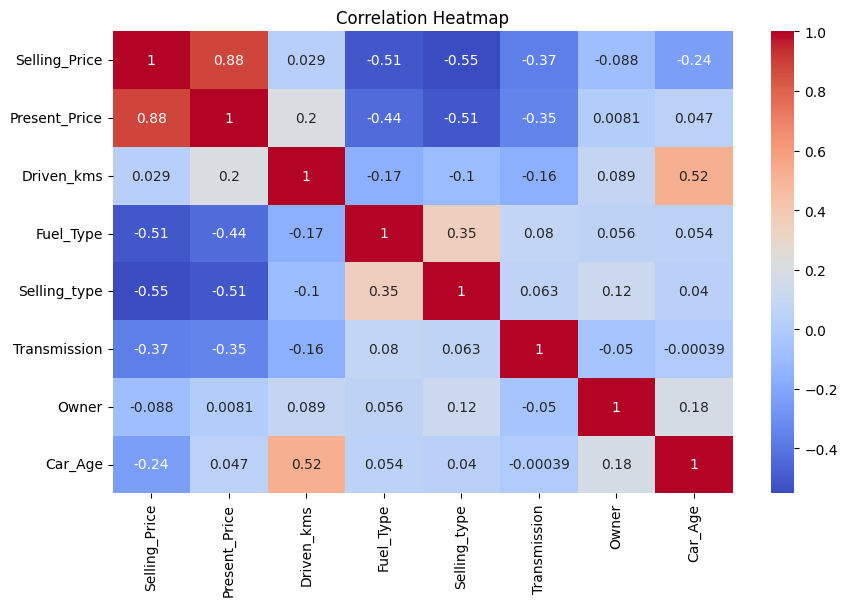


MODEL PERFORMANCE
Mean Absolute Error: 0.6389196721311476
Mean Squared Error: 0.9382767457377043
R2 Score: 0.9592683769360726


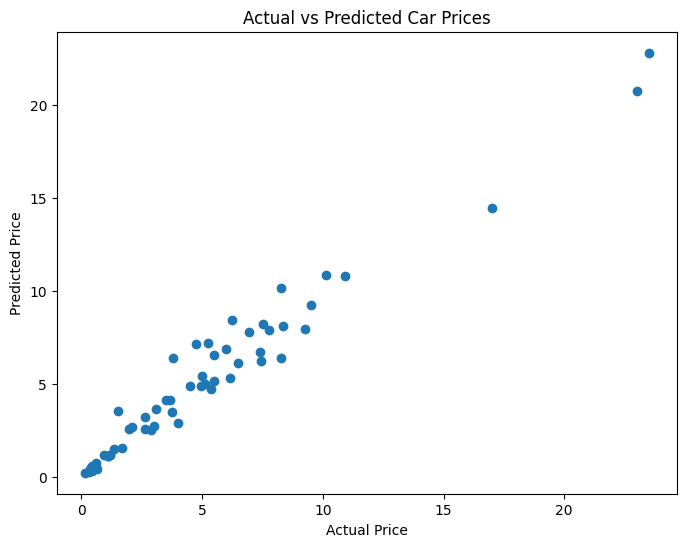

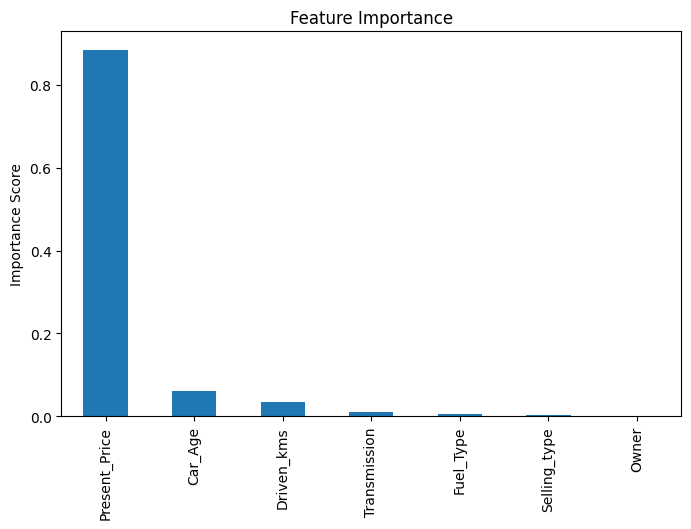


SAMPLE PREDICTION
Predicted Car Price: 3.8565000000000036

KEY FINDINGS
1. Present price is the most important factor affecting selling price.
2. Car age negatively impacts resale value.
3. Fuel type and transmission influence car pricing.
4. Random Forest Regression provides accurate price predictions.

CONCLUSION
This project successfully predicts car selling prices using machine learning. Data preprocessing, feature engineering, visualization, and model evaluation were performed to build a reliable regression model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
df = pd.read_csv('/content/car data.csv')

print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nMISSING VALUES")
print(df.isnull().sum())

# Data Cleaning
df.dropna(inplace=True)

# Feature Engineering
current_year = 2025
df['Car_Age'] = current_year - df['Year']

# Remove unnecessary columns
df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

# Encode Categorical Features
encoder = LabelEncoder()

df['Fuel_Type'] = encoder.fit_transform(df['Fuel_Type'])
df['Selling_type'] = encoder.fit_transform(df['Selling_type'])
df['Transmission'] = encoder.fit_transform(df['Transmission'])

print("\nPROCESSED DATA")
print(df.head())

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Features and Target
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model Training
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("\nMODEL PERFORMANCE")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Actual vs Predicted Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

# Feature Importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()

# Sample Prediction
sample = X.iloc[[0]]
prediction = model.predict(sample)

print("\nSAMPLE PREDICTION")
print("Predicted Car Price:", prediction[0])

# Insights
print("\nKEY FINDINGS")
print("1. Present price is the most important factor affecting selling price.")
print("2. Car age negatively impacts resale value.")
print("3. Fuel type and transmission influence car pricing.")
print("4. Random Forest Regression provides accurate price predictions.")

print("\nCONCLUSION")
print("This project successfully predicts car selling prices using machine learning. Data preprocessing, feature engineering, visualization, and model evaluation were performed to build a reliable regression model.")